# Imports

In [ ]:
# import io

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from lib.dataprep import remove_constant_features, remove_features_by_missingness_threshold



# Load data

In [ ]:
X = pd.read_csv("../data/secom.data", sep=" ", header=None, na_values="NaN")
y = pd.read_csv("../data/secom_labels.data", sep=" ", header=None, names=["label", "timestamp"])

# Background and Data Structure

In [28]:
# The SECOM dataset comes from a semiconductor wafer fabrication line. 
# Each row corresponds to one production entity (e.g., a wafer or lot at a specific test point), 
# and each column is a sensor measurement or process variable collected during manufacturing. 

# Rows: 1567 observations (wafers/tests).

# Columns (X): 590 continuous features (sensor readings).

# Labels (y):

# label = -1 → wafer passed in-house line testing (good).

# label = 1 → wafer failed (defective). 

# The labels file also contains a timestamp for each test.

# The goal is to use these sensor features to predict whether a wafer will pass or fail, 
# and to understand which features are most relevant for yield and fault detection. 

In [29]:
print(X.shape)
print(y.shape)

(1567, 590)
(1567, 2)


In [30]:
X.head()

,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [31]:
y.head()

,label,timestamp
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00


# Descriptive Statistics

In [32]:
label_counts = y["label"].value_counts().sort_index()
label_percent = y["label"].value_counts(normalize=True).sort_index() * 100

print("Label counts:\n", label_counts)
print("\nLabel percentages (%):\n", label_percent)

is_imbalanced = (label_percent.min() < 30)  # crude check
print("\nIs dataset imbalanced?", is_imbalanced)

Label counts:
 label
-1    1463
 1     104
Name: count, dtype: int64

Label percentages (%):
 label
-1    93.363114
 1     6.636886
Name: proportion, dtype: float64

Is dataset imbalanced? True


In [33]:
# Interpretation

# The percentage of defective wafers (label = 1) is small (around ~6–7%).

# The percentage of good wafers (label = -1) is large (around ~93–94%).

# This is clearly an imbalanced dataset: 
# the model could naively predict “good” most of the time and still achieve high accuracy, 
# so we must be careful with evaluation and sampling strategies.

# Missing Values

In [34]:
# Check that NaNs are present
total_missing = X.isna().sum().sum()
total_values = X.size
missing_pct_overall = total_missing / total_values * 100

print("Total missing values:", total_missing)
print("Overall missing percentage: {:.2f}%".format(missing_pct_overall))

# Quick sanity check: any 'NaN' strings left?
print("Any literal 'NaN' strings left?", (X == "NaN").any().any())


Total missing values: 41951
Overall missing percentage: 4.54%
Any literal 'NaN' strings left? False


In [35]:
missing_one = X[2].isna().mean() * 100  # percentage
print("Missing values in column 1:", missing_one)

Missing values in column 1: 0.8934269304403318


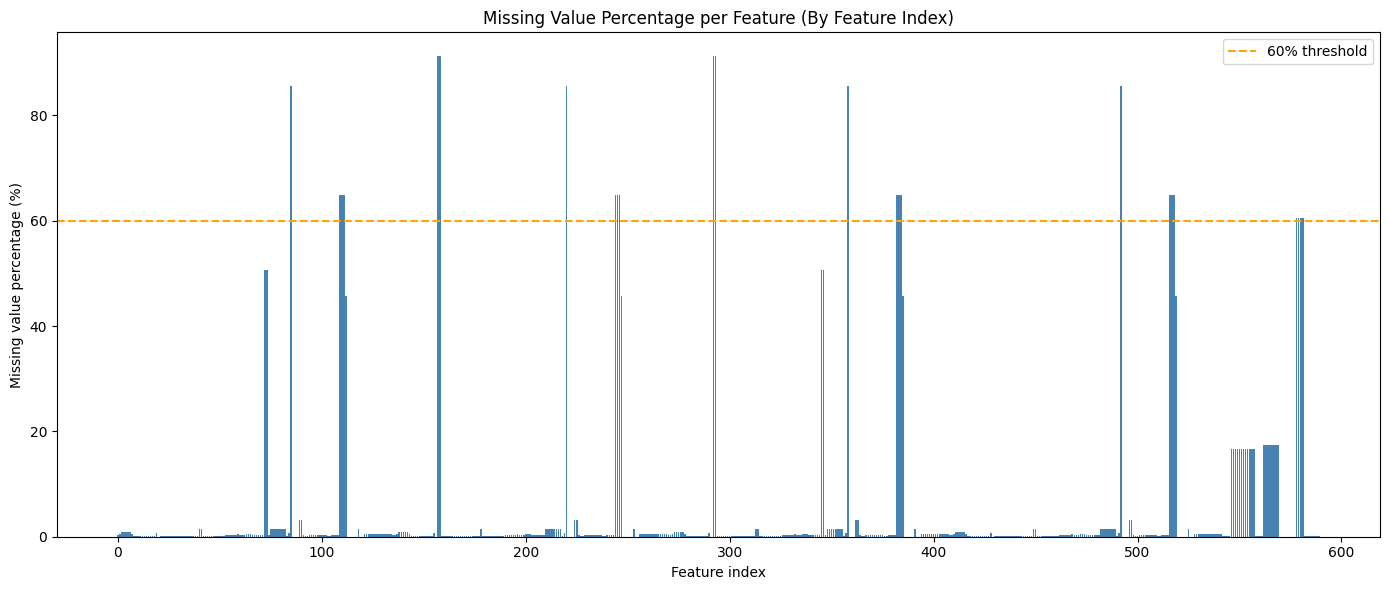

In [36]:
# Compute missing percentage per feature
missing_perc = X.isna().mean() * 100  # percentage

plt.figure(figsize=(14, 6))
plt.bar(range(len(missing_perc)), missing_perc, color='steelblue')

# Optional: add threshold lines
plt.axhline(60, color='orange', linestyle='--', label='60% threshold')

plt.xlabel("Feature index")
plt.ylabel("Missing value percentage (%)")
plt.title("Missing Value Percentage per Feature (By Feature Index)")
plt.legend()
plt.tight_layout()
plt.show()


In [37]:
# Compute missing percentage per feature
missing_perc = X.isna().mean() * 100

# Identify features exceeding 60%
high_missing_cols = missing_perc[missing_perc > 60].index.tolist()

print("Number of features with >60% missing:", len(high_missing_cols))
print("Feature indices (or names):")
print(high_missing_cols)


Number of features with >60% missing: 24
Feature indices (or names):
[85, 109, 110, 111, 157, 158, 220, 244, 245, 246, 292, 293, 358, 382, 383, 384, 492, 516, 517, 518, 578, 579, 580, 581]


In [38]:
# Interpretation

# If total_missing > 0 and no literal "NaN" strings remain, missing values are correctly flagged as np.nan.

# This is crucial for later imputation and outlier handling.

# Train/Test Split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y["label"],          # use only the label column for stratification
    test_size=0.2,
    random_state=42,
    stratify=y["label"]
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

def describe_labels(name, labels):
    counts = labels.value_counts().sort_index()
    pct = labels.value_counts(normalize=True).sort_index() * 100
    print(f"\n{name} label distribution:")
    # print("Label Count:\n", counts, "\n")
    print("Label Percentages:\n", pct.round(2))

describe_labels("Original", y["label"])
describe_labels("Train", y_train)
describe_labels("Test", y_test)

Train shape: (1253, 590) Test shape: (314, 590)

Original label distribution:
Label Percentages:
 label
-1    93.36
 1     6.64
Name: proportion, dtype: float64

Train label distribution:
Label Percentages:
 label
-1    93.38
 1     6.62
Name: proportion, dtype: float64

Test label distribution:
Label Percentages:
 label
-1    93.31
 1     6.69
Name: proportion, dtype: float64


In [40]:
# The test set is now fixed and must not be used for any further preprocessing decisions 
# (no imputation fitting, no outlier detection, no feature selection).

# All subsequent steps (missingness-based feature removal, outlier handling, etc.) 
# are done only on the training set, then applied to the test set using the same transformations.

# Rough Feature Reduction

## Constant Features

In [41]:
X_train.shape

(1253, 590)

In [42]:
X_train_reduced, removed_cols = remove_constant_features(X_train)
print(f"Removed constant features(Total of {len(removed_cols)}): ", removed_cols)

Removed constant features(Total of 116):  [5, 13, 42, 49, 52, 69, 97, 141, 149, 178, 179, 186, 189, 190, 191, 192, 193, 194, 226, 229, 230, 231, 232, 233, 234, 235, 236, 237, 240, 241, 242, 243, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 276, 284, 313, 314, 315, 322, 325, 326, 327, 328, 329, 330, 364, 369, 370, 371, 372, 373, 374, 375, 378, 379, 380, 381, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 414, 422, 449, 450, 451, 458, 461, 462, 463, 464, 465, 466, 481, 498, 501, 502, 503, 504, 505, 506, 507, 508, 509, 512, 513, 514, 515, 528, 529, 530, 531, 532, 533, 534, 535, 536, 537, 538]


In [43]:
X_train_reduced.shape

(1253, 474)

## Threshold Feature Removal

In [44]:
# Missing value percentage per column in training set
missing_perc_col = X_train_reduced.isna().mean()  # fraction per column
print(missing_perc_col.head())

0    0.003990
1    0.003990
2    0.010375
3    0.010375
4    0.010375
dtype: float64


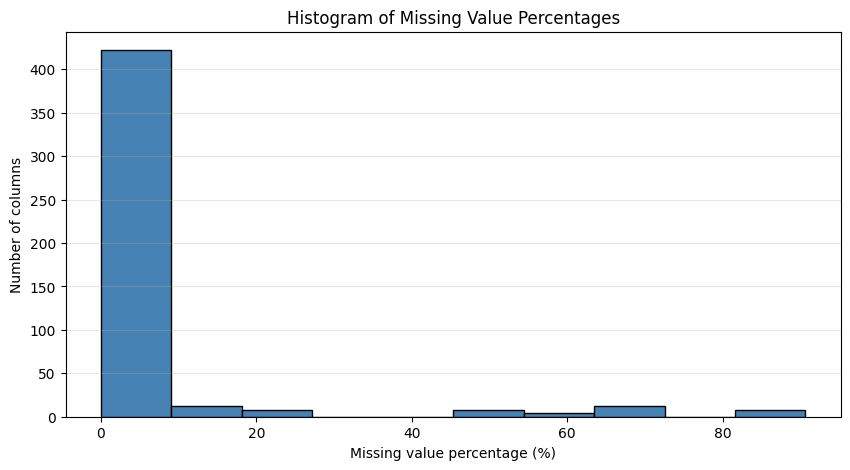

In [45]:
plt.figure(figsize=(10,5))
plt.hist(missing_perc_col * 100, bins=10, color='steelblue', edgecolor='black')
plt.xlabel("Missing value percentage (%)")
plt.ylabel("Number of columns")
plt.title("Histogram of Missing Value Percentages")
plt.grid(axis='y', alpha=0.3)
plt.show()

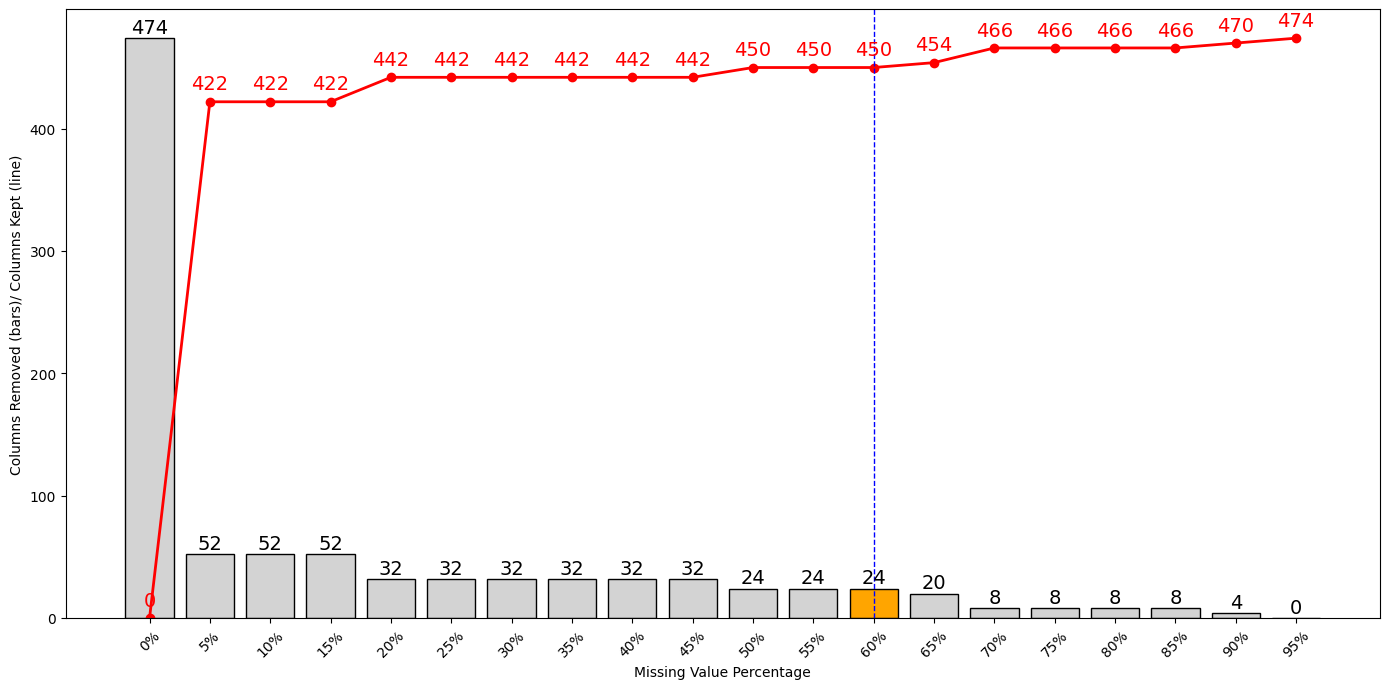

In [46]:
# --- 1. Create 5% buckets ---
bins = np.arange(0, 1.05, 0.05)   # 0%, 5%, ..., 100%
labels = [f"{int(b*100)}%" for b in bins[:-1]]   # <-- FIXED: show only 0, 5, 10, ...

# --- 2. Compute columns removed for each bucket ---
removed_counts = []
for b in bins[:-1]:
    removed = (missing_perc_col >= b).sum()
    removed_counts.append(removed)

removed_counts = pd.Series(removed_counts, index=labels)

# --- 3. FIXED cumulative line: columns kept ---
total_cols = len(missing_perc_col)
cum_removed = total_cols - removed_counts   # decreasing line

plt.figure(figsize=(14,7))

# --- 4. Highlight only the 55–60% bucket ---
highlight_bucket = "60%"   # because 55–60% bucket now labeled "60%"
colors = [
    "orange" if label == highlight_bucket else "lightgray"
    for label in removed_counts.index
]

# --- 5. Plot bars ---
bars = plt.bar(removed_counts.index, removed_counts.values,
               color=colors, edgecolor='black')

# --- 6. Add value labels on top of bars ---
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        str(int(height)),
        ha='center', va='bottom',
        fontsize=14
    )

# --- 7. Add decreasing cumulative line (starts at 474, ends at 0) ---
plt.plot(removed_counts.index, cum_removed, color='red', marker='o', linewidth=2)

# --- 8. Label cumulative points ---
for x, y in zip(removed_counts.index, cum_removed):
    plt.text(x, y + 10, str(int(y)), ha='center', fontsize=14, color='red')

plt.axvline('60%', color='blue', linestyle='--', linewidth=1)

plt.xticks(rotation=45)
plt.xlabel("Missing Value Percentage")
plt.ylabel("Columns Removed (bars)/ Columns Kept (line)")
# plt.title("Pareto Chart: Missing Percentage vs. Columns Removed")
plt.tight_layout()
plt.show()

In [47]:
X_train_reduced.shape

(1253, 474)

In [48]:
X_train_reduced, high_missing_cols = remove_features_by_missingness_threshold(X_train_reduced, threshold=60)
print(f"Removed features (Total of {len(high_missing_cols)}): ", high_missing_cols)

Removed features (Total of 24):  [85, 109, 110, 111, 157, 158, 220, 244, 245, 246, 292, 293, 358, 382, 383, 384, 492, 516, 517, 518, 578, 579, 580, 581]


In [49]:
X_train_reduced.shape

(1253, 450)

# Correlation Heatmap

(no removal yet based on correlation)

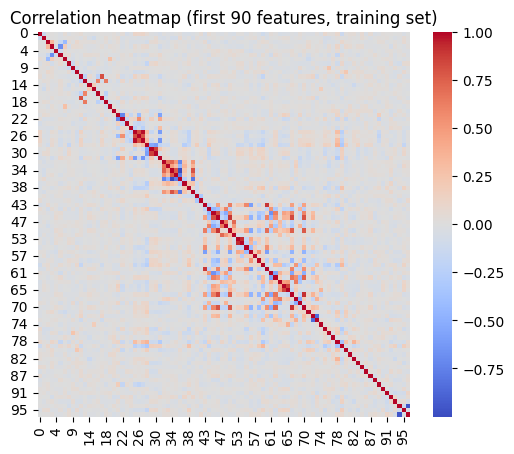

In [50]:
# To keep the heatmap readable, sample first N features
N = min(90, X_train_reduced.shape[1])
subset = X_train_reduced.iloc[:, :N]

corr_matrix = subset.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title(f"Correlation heatmap (first {N} features, training set)")
plt.show()

In [51]:
# The heatmap shows blocks of highly correlated sensors, indicating redundancy.

# Although some approaches remove features with |r| > 0.8, 
# we defer correlation-based feature removal to a later, more principled method.

# Outlier treatment

In [52]:
# Compute mean and std for each feature
means = X_train_reduced.mean()
stds = X_train_reduced.std()

# Compute boundaries
lower_bound = means - 3 * stds
upper_bound = means + 3 * stds

In [ ]:
X_train_capped = X_train_reduced.copy()

for col in X_train_capped.columns:
    X_train_capped[col] = np.clip(
        X_train_capped[col],
        lower_bound[col],
        upper_bound[col]
    )

In [ ]:
def cap_outlier_using_3sigma_rule(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Caps outliers in the DataFrame using the 3-sigma rule.
    For each feature, values outside the range [mean - 3*std, mean + 3*std] are capped to the respective boundary.
    """

    means = data.mean()
    stds = data.std()
    lower_bound = means - 3 * stds
    upper_bound = means + 3 * stds

    for col in data.columns:
        data[col] = np.clip(
            data[col],
            lower_bound[col],
            upper_bound[col]
        )
    
    return data

In [55]:
X_train_reduced.describe().T[['mean','std','min','max']].head()

,mean,std,min,max
0,3014.207228,73.029160,2743.2400,3356.3500
1,2496.611378,80.102790,2162.8700,2846.4400
2,2200.151328,29.445513,2060.6600,2315.2667
3,1387.511151,431.115520,711.0258,3715.0417
4,3.124149,44.594150,0.6815,1112.1600


In [56]:
X_train_capped.describe().T[['mean','std','min','max']].head()

,mean,std,min,max
0,3013.955963,71.659868,2795.119746,3233.294709
1,2496.351970,77.495334,2256.303008,2736.919748
2,2200.321383,28.194641,2111.814788,2288.487868
3,1378.528526,395.721052,711.025800,2680.857711
4,1.551227,5.458309,0.681500,136.906600


In [57]:
capped_mask = (X_train_capped != X_train_reduced)
capped_counts = capped_mask.sum()
capped_counts[capped_counts > 0].sort_values(ascending=False).head()

345    628
346    628
73     624
72     623
247    582
dtype: int64

In [59]:
capped_mask.sum()

0      17
1      22
2      23
3      37
4      15
       ..
585     3
586    12
587    16
588    18
589    39
Length: 450, dtype: int64

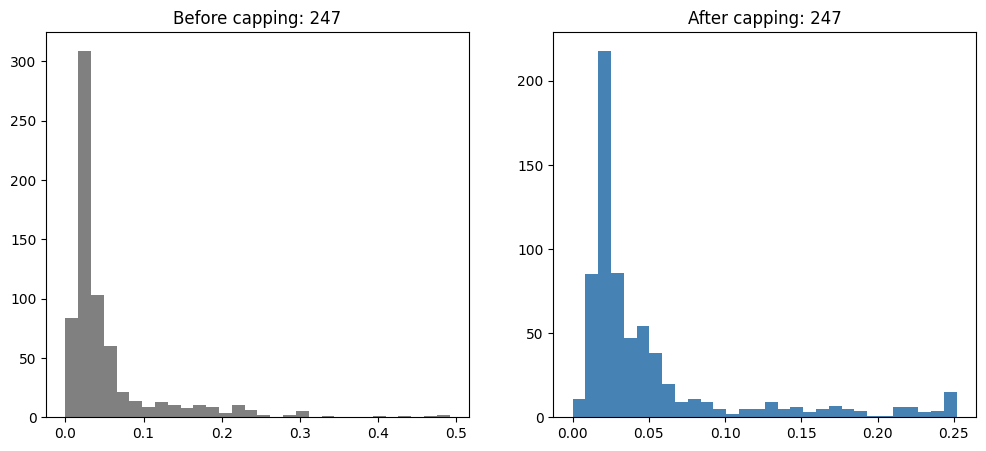

In [348]:
feature = capped_counts.sort_values(ascending=False).index[4]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(X_train_reduced[feature], bins=30, color='gray')
plt.title(f"Before capping: {feature}")

plt.subplot(1,2,2)
plt.hist(X_train_capped[feature], bins=30, color='steelblue')
plt.title(f"After capping: {feature}")

plt.show()


In [349]:
total_changes = capped_mask.sum().sum()
total_changes


np.int64(16083)

In [350]:
total_values = X_train_reduced.size
total_values


563850

In [351]:
percentage_changed = total_changes / total_values * 100

print(f"Percentage of values changed by capping: {percentage_changed:.2f}%")

Percentage of values changed by capping: 2.85%


In [352]:
X_train_reduced = X_train_capped

# Build First Model: Random Forest

In [353]:
# Replace common placeholders with proper NaN
X_train_reduced = X_train_reduced.replace(
    ["", " ", "?", "NA", "N/A", "nan", "None", -999, 999],
    np.nan
)

In [ ]:
# # Split your data BEFORE scaling + imputation
# X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
#     X_train_reduced, y_train, test_size=0.2, random_state=42
# )

In [361]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("imputer", KNNImputer(n_neighbors=5)),
    ("rf", RandomForestClassifier(n_estimators=200, random_state=42))
])

pipe.fit(X_train_reduced, y_train)

val_acc = pipe.score(X_train_reduced, y_train)
print("Validation accuracy:", val_acc)

Validation accuracy: 1.0


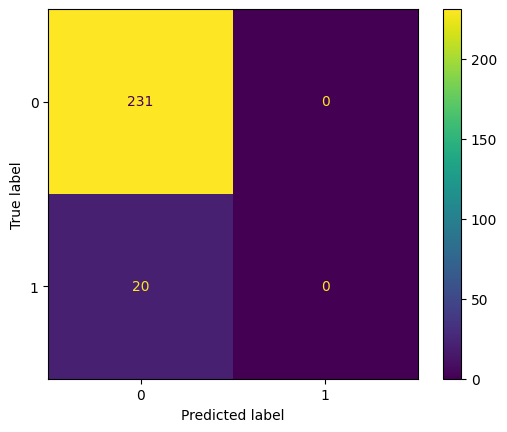

In [ ]:
# # Check the confusion matrix
# y_val_pred = pipe.predict(X_val_split)

# cm = confusion_matrix(y_val_split, y_val_pred)
# disp = ConfusionMatrixDisplay(cm)
# disp.plot()

In [ ]:
# print(classification_report(y_val_split, y_val_pred))

              precision    recall  f1-score   support

          -1       0.92      1.00      0.96       231
           1       0.00      0.00      0.00        20

    accuracy                           0.92       251
   macro avg       0.46      0.50      0.48       251
weighted avg       0.85      0.92      0.88       251



c:\Users\ThanakornRunglerdkri\OneDrive - Hochschule für Technik und Wirtschaft Berlin\Documents\repos\secomproject\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ThanakornRunglerdkri\OneDrive - Hochschule für Technik und Wirtschaft Berlin\Documents\repos\secomproject\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ThanakornRunglerdkri\OneDrive - Hochschule für Technik und Wirtschaft Berlin\Documents\repos\secomproject\venv\Lib\site-packages\sklearn\metrics\_classif

In [ ]:
# pipe = Pipeline([
#     ("scaler", StandardScaler()),
#     ("imputer", KNNImputer()),
#     ("rf", RandomForestClassifier(random_state=42))
# ])

# param_grid = {
#     "imputer__n_neighbors": [3, 5, 7, 9, 11],
#     "rf__n_estimators": [100, 200, 300]
# }

# grid = GridSearchCV(pipe, param_grid, cv=3, scoring="accuracy", n_jobs=-1)
# grid.fit(X_train_split, y_train_split)

# print("Best params:", grid.best_params_)
# print("Best CV score:", grid.best_score_)


Best params: {'imputer__n_neighbors': 3, 'rf__n_estimators': 100}
Best CV score: 0.9371257485029941


# Evaluate on Test Set

In [ ]:
# pipe = Pipeline([
#     ("scaler", StandardScaler()),
#     ("imputer", KNNImputer(n_neighbors=3)),
#     ("rf", RandomForestClassifier(n_estimators=100, random_state=42))
# ])

# pipe.fit(X_train_reduced, y_train)

# # val_acc = pipe.score(X_val_split, y_val_split)
# # print("Validation accuracy:", val_acc)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('imputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"missing_values missing_values: int, float, str, np.nan or None, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to np.nan, since `pd.NA` will be converted to np.nan.",nan
,"n_neighbors n_neighbors: int, default=5Number of neighboring samples to use for imputation.",3
,"weights weights: {'uniform', 'distance'} or callable, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- callable : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.",'uniform'
,"metric metric: {'nan_euclidean'} or callable, default='nan_euclidean'Distance metric for searching neighbors. Possible values:- 'nan_euclidean'- callable : a user-defined function which conforms to the definition of ``func_metric(x, y, *, missing_values=np.nan)``. `x` and `y` corresponds to a row (i.e. 1-D arrays) of `X` and `Y`, respectively. The callable should returns a scalar distance value.",'nan_euclidean'


In [360]:
test_acc = pipe.score(X_test, y_test)
print("Test accuracy:", test_acc)

ValueError: X has 590 features, but StandardScaler is expecting 450 features as input.